<a href="https://colab.research.google.com/github/imadeardanabapeten/Analisis-Sentimen-Aplikasi-Access-by-KAI/blob/main/Analisis_Sentimen_Access_by_KAI_16022026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Import Library***

In [9]:
# === Data handling ===
import pandas as pd
import numpy as np
import re

# === Visualisasi ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Machine Learning (SVM) ===
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ***Load Data Hasil Scraping***

In [10]:
df = pd.read_csv("hasil_scraper_ulasan_APP_1.csv")

# Cek 10 data teratas
df.head(50)

,reviewId,userName,rating,review_txt,date
0,d4e4902d-5b78-46b3-adf3-ff69e8f76430,Pengguna Google,5,bagus banget,2026-02-04 13:16:13
1,5b2dc292-306f-4a3c-86a7-3e89f1a8bc92,Pengguna Google,5,mantap,2026-02-04 12:49:36
2,5737aa63-e8f9-47d1-9c7b-363c0aba881b,Pengguna Google,5,luar biasa...mantap... terimakasih pelayanan nya,2026-02-04 12:13:15
3,91bef259-f403-4483-996c-8231a42e6ba8,Pengguna Google,1,makin di-update makin banyak masalah nya,2026-02-04 11:24:02
4,cd27b68a-fdac-474f-8b62-de861f3af48c,Pengguna Google,5,"sebenarnya aplikasi ini memudahkan,tp knp bebe...",2026-02-04 09:45:24
5,3133fcd5-7ebb-4abe-9032-35faaeecb443,Pengguna Google,5,sngt membatu,2026-02-04 08:41:29
6,823e3abc-343d-4ea6-a41c-24307dddeb2c,Pengguna Google,5,kenapa war tiket lebaran tahun ini susah bange...,2026-02-04 08:33:13
7,6c267913-399d-4637-b314-09ca266fa632,Pengguna Google,5,cepat,2026-02-04 08:02:44
8,fed9b129-2536-47ec-b349-bccb597bdf72,Pengguna Google,5,mantap,2026-02-04 07:30:16
9,5ad20112-84c0-4fc3-a11b-5130882ea6f1,Pengguna Google,5,good,2026-02-04 05:51:30


# ***Analisis Distribusi Ratng Pengguna***

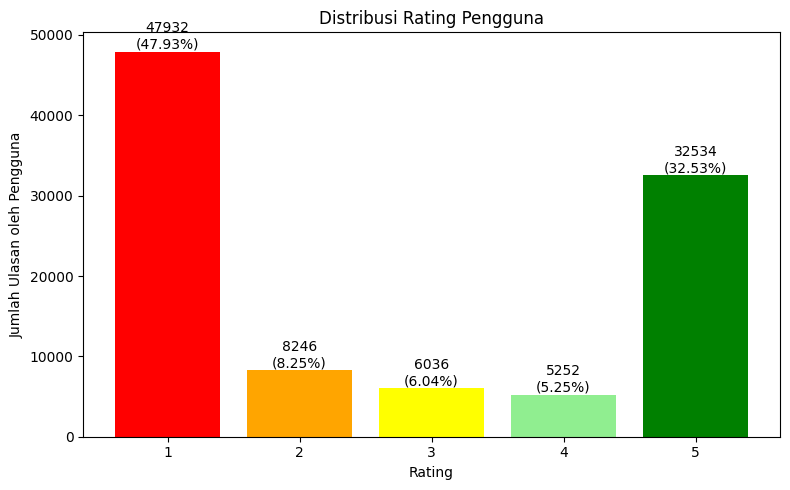

In [11]:
df = pd.read_csv("hasil_scraper_ulasan_APP_1.csv")

# Pastikan rating numerik
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Hitung distribusi rating 1–5
distribusi = (
    df['rating']
    .value_counts()
    .reindex([1, 2, 3, 4, 5], fill_value=0)
    .sort_index()
)

total = distribusi.sum()
persentase = (distribusi / total) * 100

# Warna berbeda untuk tiap rating
colors = ['red', 'orange', 'yellow', 'lightgreen', 'green']

# Membuat grafik
plt.figure(figsize=(8, 5))
bars = plt.bar(distribusi.index, distribusi.values, color=colors)

plt.xlabel("Rating")
plt.ylabel("Jumlah Ulasan oleh Pengguna")
plt.title("Distribusi Rating Pengguna")
plt.xticks([1, 2, 3, 4, 5])

# Menambahkan jumlah & persentase di atas batang
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height}\n({persentase.iloc[i]:.2f}%)",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

# ***Seleksi kolom dan duplikasi***

In [12]:
df_prep = df[['review_txt', 'rating']].copy()

# Cek duplikasi teks
df_prep.duplicated(subset='review_txt').sum()

np.int64(16598)

# ***Membuang Duplikasi***

In [13]:
df_prep = df_prep.drop_duplicates(subset='review_txt')
df_prep.shape

(83402, 2)

# ***Case Folding (Mengubah Semua Huruf Menjadi Huruf Kecil)***

In [14]:
#Ambil ulang teks asli
df_prep['review_txt_original'] = df.loc[df_prep.index, 'review_txt']

#Buat hasil case folding dari teks asli
df_prep['review_txt_casefold'] = df_prep['review_txt_original'].str.lower()

#Tampilkan perbandingan
df_prep[['review_txt_original', 'review_txt_casefold']].head(50)

,review_txt_original,review_txt_casefold
0,bagus banget,bagus banget
1,mantap,mantap
2,luar biasa...mantap... terimakasih pelayanan nya,luar biasa...mantap... terimakasih pelayanan nya
3,makin di-update makin banyak masalah nya,makin di-update makin banyak masalah nya
4,"sebenarnya aplikasi ini memudahkan,tp knp bebe...","sebenarnya aplikasi ini memudahkan,tp knp bebe..."
5,sngt membatu,sngt membatu
6,kenapa war tiket lebaran tahun ini susah bange...,kenapa war tiket lebaran tahun ini susah bange...
7,cepat,cepat
9,good,good
10,sangat keren,sangat keren


# ***Cleaning Teks***

In [15]:
def clean_text(text):
    text = re.sub(r'http\S+', '', text)      # hapus URL
    text = re.sub(r'[^a-z\s]', ' ', text)    # hapus angka & simbol
    text = re.sub(r'\s+', ' ', text).strip() # rapikan spasi
    return text

df_prep['review_txt_clean'] = df_prep['review_txt_casefold'].apply(clean_text)

df_prep[['review_txt_casefold', 'review_txt_clean']].head(50)

,review_txt_casefold,review_txt_clean
0,bagus banget,bagus banget
1,mantap,mantap
2,luar biasa...mantap... terimakasih pelayanan nya,luar biasa mantap terimakasih pelayanan nya
3,makin di-update makin banyak masalah nya,makin di update makin banyak masalah nya
4,"sebenarnya aplikasi ini memudahkan,tp knp bebe...",sebenarnya aplikasi ini memudahkan tp knp bebe...
5,sngt membatu,sngt membatu
6,kenapa war tiket lebaran tahun ini susah bange...,kenapa war tiket lebaran tahun ini susah bange...
7,cepat,cepat
9,good,good
10,sangat keren,sangat keren


# ***Menghapus Stopword (Kata Tidak Bermakna)***

In [16]:
# Install Sastrawi (hanya perlu sekali)
!pip install Sastrawi

# Import library stopword
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stop_factory = StopWordRemoverFactory()
stopwords = stop_factory.get_stop_words()

# Fungsi hapus stopword
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords])

# Terapkan ke kolom clean
df_prep['review_txt_nostop'] = df_prep['review_txt_clean'].apply(remove_stopwords)

# Tampilkan perbandingan
df_prep[['review_txt_clean', 'review_txt_nostop']].head(50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.7 MB/s eta 0:00:00


,review_txt_clean,review_txt_nostop
0,bagus banget,bagus banget
1,mantap,mantap
2,luar biasa mantap terimakasih pelayanan nya,luar biasa mantap terimakasih pelayanan nya
3,makin di update makin banyak masalah nya,makin update makin banyak masalah nya
4,sebenarnya aplikasi ini memudahkan tp knp bebe...,sebenarnya aplikasi memudahkan tp knp beberapa...
5,sngt membatu,sngt membatu
6,kenapa war tiket lebaran tahun ini susah bange...,war tiket lebaran tahun susah banget min udah ...
7,cepat,cepat
9,good,good
10,sangat keren,sangat keren


# ***Stemming*** (Mengubah Kata ke Bentuk Dasar)

In [17]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Buat stemmer
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

# Terapkan ke kolom yang sudah stopword removal
df_prep['review_txt_stemmed'] = df_prep['review_txt_nostop'].apply(stemmer.stem)

# Tampilkan perbandingan
df_prep[['review_txt_nostop', 'review_txt_stemmed']].head(10)

,review_txt_nostop,review_txt_stemmed
0,bagus banget,bagus banget
1,mantap,mantap
2,luar biasa mantap terimakasih pelayanan nya,luar biasa mantap terimakasih layan nya
3,makin update makin banyak masalah nya,makin update makin banyak masalah nya
4,sebenarnya aplikasi memudahkan tp knp beberapa...,benar aplikasi mudah tp knp beberapa hari susa...
5,sngt membatu,sngt batu
6,war tiket lebaran tahun susah banget min udah ...,war tiket lebaran tahun susah banget min udah ...
7,cepat,cepat
9,good,good
10,sangat keren,sangat keren


# ***Tahap Labeling***

In [18]:
# Fungsi untuk assign sentimen
def assign_sentiment(rating):
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    else:
        return 'negatif'

# Terapkan ke kolom rating
df_prep['sentiment'] = df_prep['rating'].apply(assign_sentiment)

# Cek distribusi
print(df_prep['sentiment'].value_counts())

# Tampilkan beberapa baris pertama (50 baris)
df_prep[['review_txt_stemmed', 'rating', 'sentiment']].head(50)

sentiment
negatif    54544
positif    23162
netral      5696
Name: count, dtype: int64


,review_txt_stemmed,rating,sentiment
0,bagus banget,5,positif
1,mantap,5,positif
2,luar biasa mantap terimakasih layan nya,5,positif
3,makin update makin banyak masalah nya,1,negatif
4,benar aplikasi mudah tp knp beberapa hari susa...,5,positif
5,sngt batu,5,positif
6,war tiket lebaran tahun susah banget min udah ...,5,positif
7,cepat,5,positif
9,good,5,positif
10,sangat keren,5,positif


# ***TF-IDF Vectorization***

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Gunakan kolom hasil stemming
corpus = df_prep['review_txt_stemmed']

# Buat vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,     # ambil 5000 kata paling penting
    ngram_range=(1,2),     # unigram + bigram
    min_df=3,              # kata muncul minimal 3 dokumen
    max_df=0.9             # kata muncul di >90% dokumen diabaikan
)

# Fit dan transformasi teks menjadi matriks TF-IDF
X = tfidf.fit_transform(corpus)

# Target label: sentiment yang sudah dibuat
y = df_prep['sentiment']

# Cek bentuk matriks
print("Bentuk matriks TF-IDF:", X.shape)

Bentuk matriks TF-IDF: (83402, 5000)


# ***Split Data Train & Test (Revisi Ulasan)***

In [20]:
from sklearn.model_selection import train_test_split

# Split data TF-IDF menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cek ukuran data dan distribusi label
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Distribusi label di data train:\n", y_train.value_counts())
print("Distribusi label di data test:\n", y_test.value_counts())

Ukuran X_train: (66721, 5000)
Ukuran X_test: (16681, 5000)
Distribusi label di data train:
 sentiment
negatif    43635
positif    18529
netral      4557
Name: count, dtype: int64
Distribusi label di data test:
 sentiment
negatif    10909
positif     4633
netral      1139
Name: count, dtype: int64


# ***Training Model SVM***

In [21]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# Buat model SVM
svm_model = LinearSVC(random_state=42, max_iter=10000)

# Training model dengan data latih
svm_model.fit(X_train, y_train)

# Prediksi data uji
y_pred = svm_model.predict(X_test)

# Evaluasi performa
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[10334    30   545]
 [  905    12   222]
 [ 1030    12  3591]]

Classification Report:
              precision    recall  f1-score   support

     negatif       0.84      0.95      0.89     10909
      netral       0.22      0.01      0.02      1139
     positif       0.82      0.78      0.80      4633

    accuracy                           0.84     16681
   macro avg       0.63      0.58      0.57     16681
weighted avg       0.79      0.84      0.81     16681



# ***Pembuatan Word Cloud***

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(text, title):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis'  # bisa diganti sesuai preferensi
    ).generate(text)

    plt.figure(figsize=(15,7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

# ***WordCloud Positif***

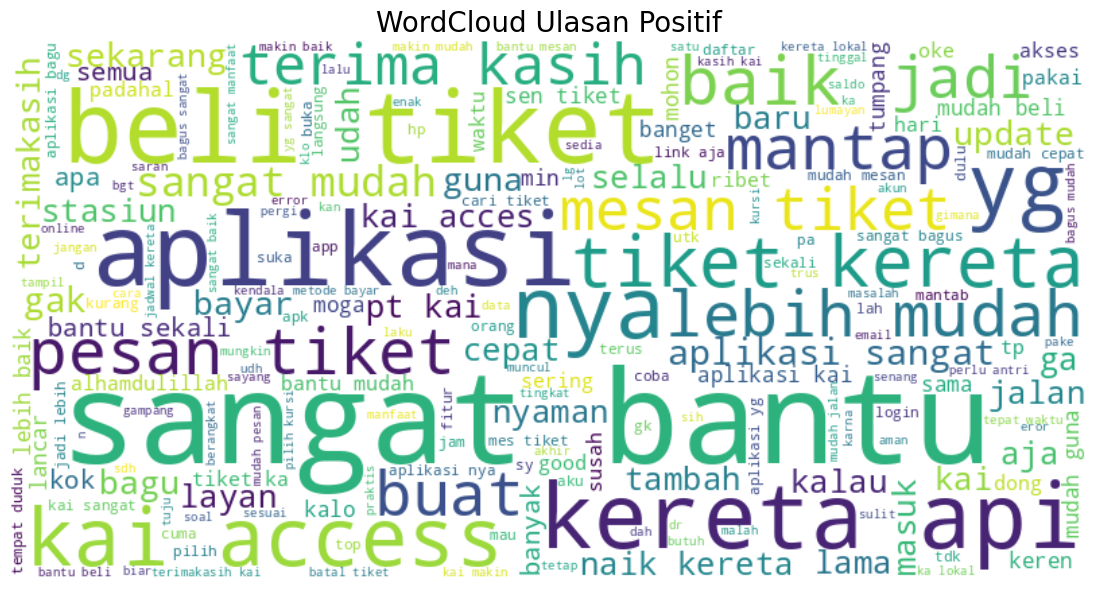

In [23]:

# Gabungkan semua ulasan positif
text_pos = ' '.join(df_prep[df_prep['sentiment']=='positif']['review_txt_stemmed'].tolist())

# Tampilkan WordCloud
plot_wordcloud(text_pos, "WordCloud Ulasan Positif")

# ***Word Cloud Ulasan Netral***

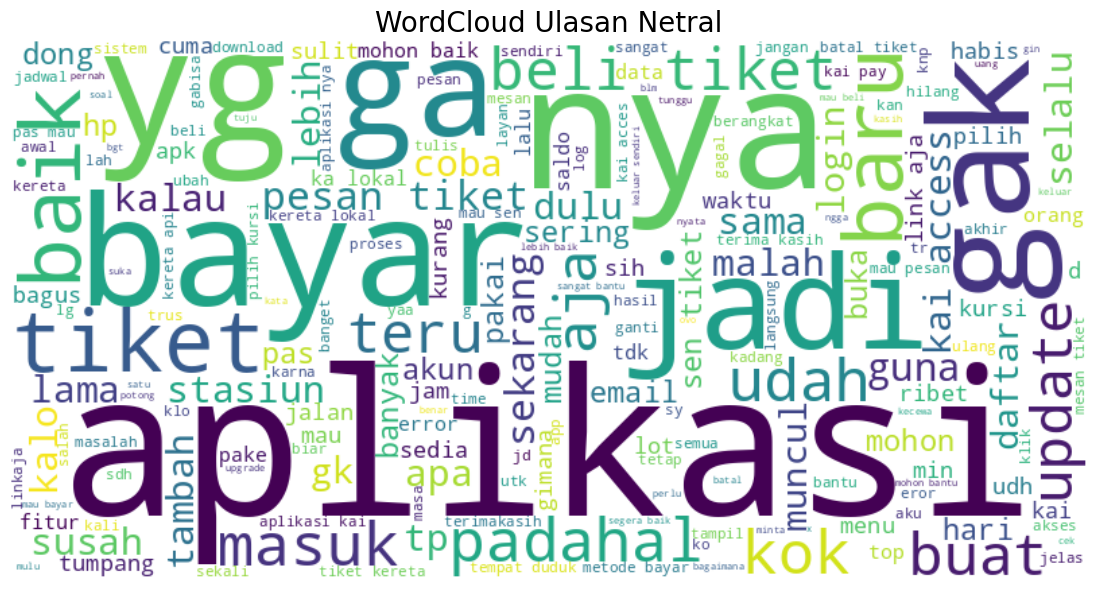

In [24]:
# Gabungkan semua ulasan netral
text_neutral = ' '.join(df_prep[df_prep['sentiment']=='netral']['review_txt_stemmed'].tolist())

# Tampilkan WordCloud
plot_wordcloud(text_neutral, "WordCloud Ulasan Netral")



# ***Word CLoud Ulasan Negatif***

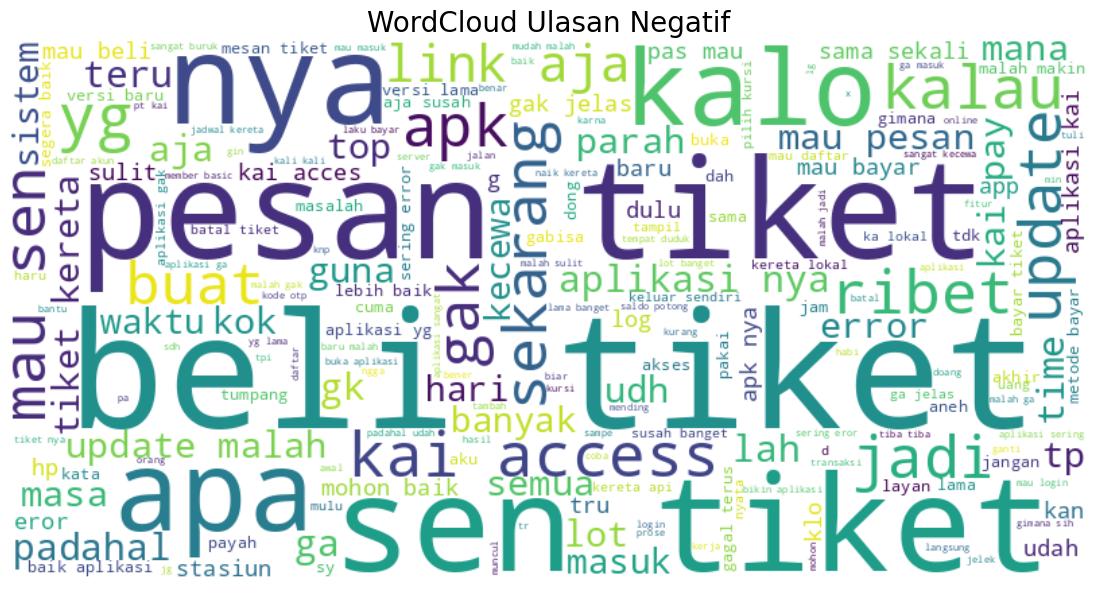

In [25]:
# Gabungkan semua ulasan negatif
text_neg = ' '.join(df_prep[df_prep['sentiment']=='negatif']['review_txt_stemmed'].tolist())

# Tampilkan WordCloud
plot_wordcloud(text_neg, "WordCloud Ulasan Negatif")

# ***Top 10 Kata per Sentimen***

In [27]:
import pandas as pd
from collections import Counter

# Fungsi untuk menghitung top n kata
def top_n_words(text_series, n=10):
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# ***Top 10 Kata Positif***

In [28]:

# 1️⃣ Top 10 Kata Positif
top_pos = top_n_words(df_prep[df_prep['sentiment']=='positif']['review_txt_stemmed'], 10)
df_top_pos = pd.DataFrame(top_pos, columns=['Kata', 'Frekuensi'])
print("Top 10 Kata Positif:")
display(df_top_pos)

Top 10 Kata Positif:


,Kata,Frekuensi
0,tiket,5280
1,mudah,4747
2,sangat,4551
3,kai,4346
4,aplikasi,3940
5,bantu,3352
6,kereta,2803
7,bagus,2226
8,lebih,2040
9,baik,1869


# ***Top 10 Kata Negatif***

In [29]:

# 3️⃣ Top 10 Kata Negatif
top_neg = top_n_words(df_prep[df_prep['sentiment']=='negatif']['review_txt_stemmed'], 10)
df_top_neg = pd.DataFrame(top_neg, columns=['Kata', 'Frekuensi'])
print("Top 10 Kata Negatif:")
display(df_top_neg)

Top 10 Kata Negatif:


,Kata,Frekuensi
0,aplikasi,23052
1,tiket,20166
2,mau,11621
3,gak,9974
4,nya,9775
5,ga,9592
6,bayar,9406
7,malah,9280
8,kai,8454
9,aja,7944


# ***Top 10 Kata Netral***

In [30]:
# 2️⃣ Top 10 Kata Netral
top_neutral = top_n_words(df_prep[df_prep['sentiment']=='netral']['review_txt_stemmed'], 10)
df_top_neutral = pd.DataFrame(top_neutral, columns=['Kata', 'Frekuensi'])
print("Top 10 Kata Netral:")
display(df_top_neutral)

Top 10 Kata Netral:


,Kata,Frekuensi
0,tiket,2006
1,aplikasi,1661
2,bayar,1186
3,mau,1115
4,nya,1002
5,kai,968
6,baik,950
7,yg,861
8,gak,706
9,update,673


# ***Gabungan Seluruh Sentimen***

In [31]:
import pandas as pd
from collections import Counter

# Fungsi menghitung Top N kata
def top_n_words(text_series, n=10):
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Ambil Top 10 kata tiap sentimen
top_pos = top_n_words(df_prep[df_prep['sentiment']=='positif']['review_txt_stemmed'], 10)
top_neutral = top_n_words(df_prep[df_prep['sentiment']=='netral']['review_txt_stemmed'], 10)
top_neg = top_n_words(df_prep[df_prep['sentiment']=='negatif']['review_txt_stemmed'], 10)

# Gabungkan menjadi satu DataFrame
df_top_words = pd.DataFrame({
    'Kata Positif': [w[0] for w in top_pos],
    'Frekuensi Positif': [w[1] for w in top_pos],
    'Kata Netral': [w[0] for w in top_neutral],
    'Frekuensi Netral': [w[1] for w in top_neutral],
    'Kata Negatif': [w[0] for w in top_neg],
    'Frekuensi Negatif': [w[1] for w in top_neg]
})

# Tampilkan tabel
df_top_words

,Kata Positif,Frekuensi Positif,Kata Netral,Frekuensi Netral,Kata Negatif,Frekuensi Negatif
0,tiket,5280,tiket,2006,aplikasi,23052
1,mudah,4747,aplikasi,1661,tiket,20166
2,sangat,4551,bayar,1186,mau,11621
3,kai,4346,mau,1115,gak,9974
4,aplikasi,3940,nya,1002,nya,9775
5,bantu,3352,kai,968,ga,9592
6,kereta,2803,baik,950,bayar,9406
7,bagus,2226,yg,861,malah,9280
8,lebih,2040,gak,706,kai,8454
9,baik,1869,update,673,aja,7944


# **Bar Chart Top 10 Kata per Sentimen**

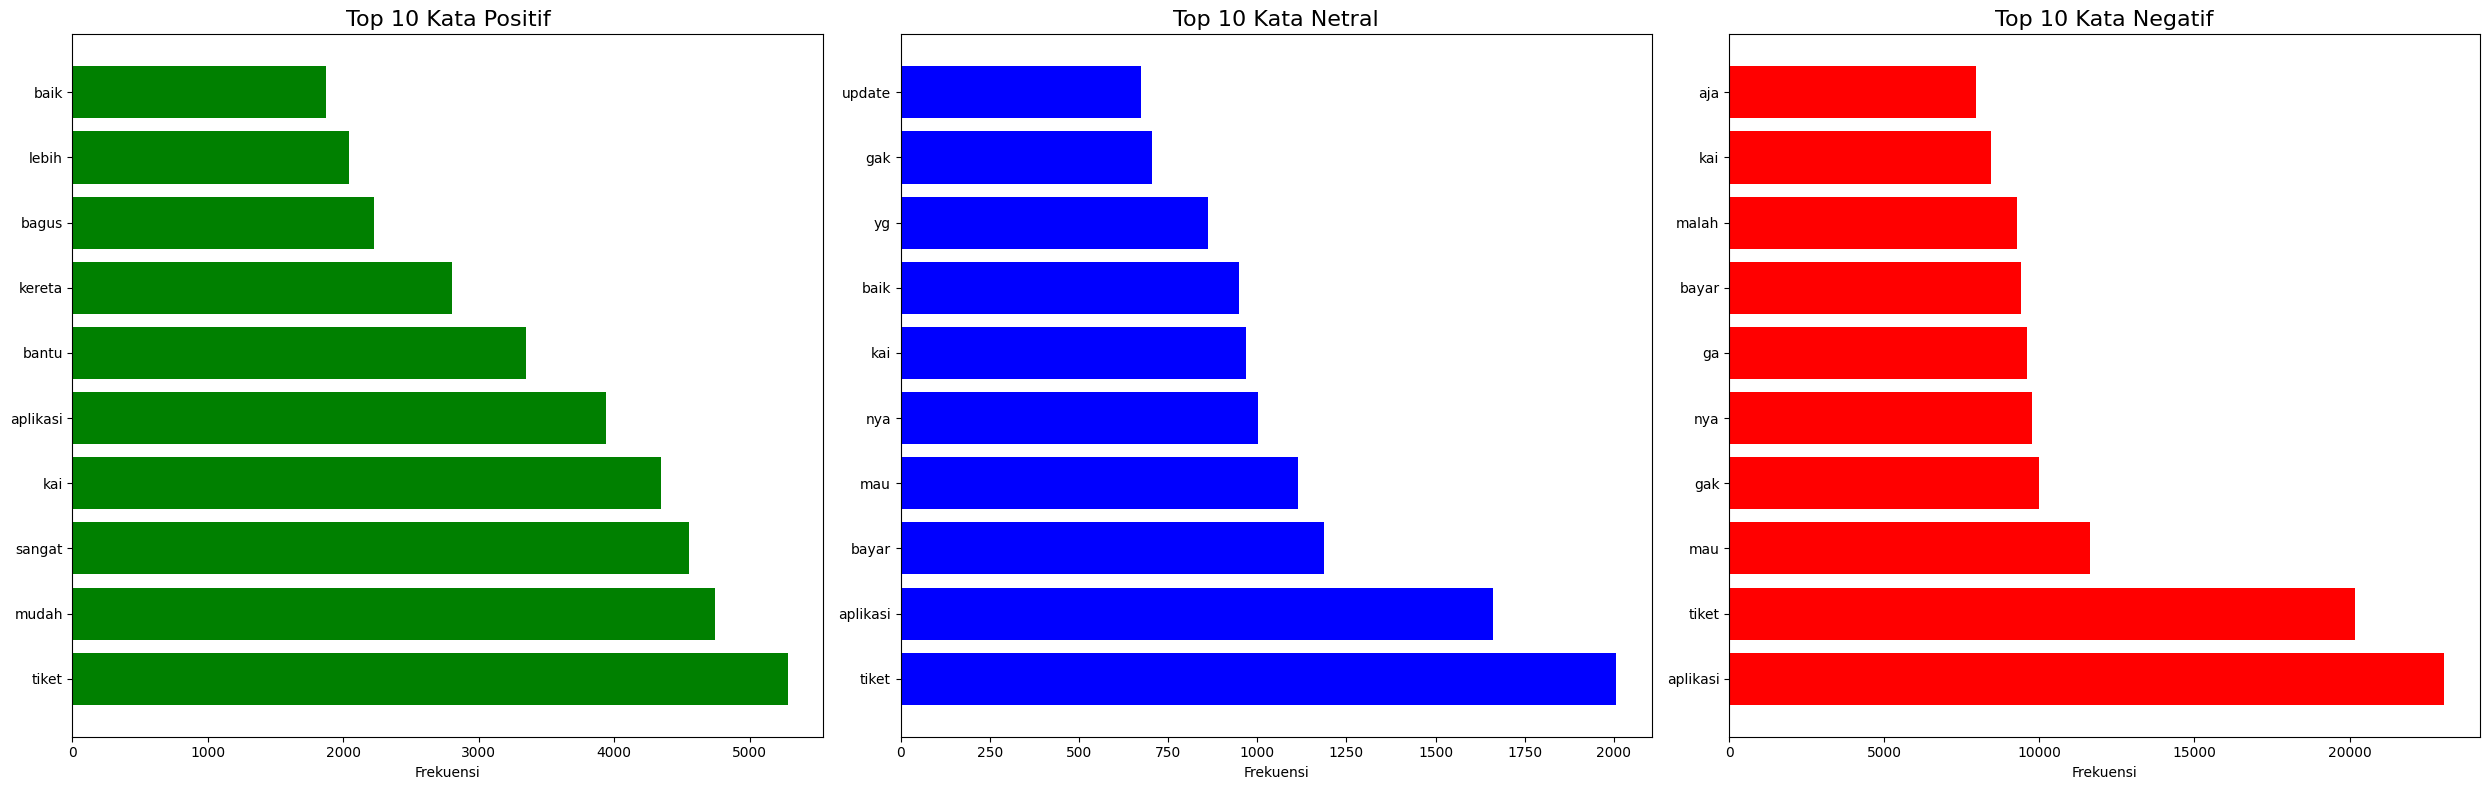

In [32]:
import matplotlib.pyplot as plt

# Buat figure dengan 3 subplot berdampingan
fig, axes = plt.subplots(1, 3, figsize=(25, 8))

# Positif
axes[0].barh([w[0] for w in top_pos][::-1], [w[1] for w in top_pos][::-1], color='green')
axes[0].set_title('Top 10 Kata Positif', fontsize=16)
axes[0].set_xlabel('Frekuensi')
axes[0].invert_yaxis()  # kata terbanyak di atas

# Netral
axes[1].barh([w[0] for w in top_neutral][::-1], [w[1] for w in top_neutral][::-1], color='blue')
axes[1].set_title('Top 10 Kata Netral', fontsize=16)
axes[1].set_xlabel('Frekuensi')
axes[1].invert_yaxis()

# Negatif
axes[2].barh([w[0] for w in top_neg][::-1], [w[1] for w in top_neg][::-1], color='red')
axes[2].set_title('Top 10 Kata Negatif', fontsize=16)
axes[2].set_xlabel('Frekuensi')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# ***Kombinasi WordCloud + Bar Chart per Sentimen***

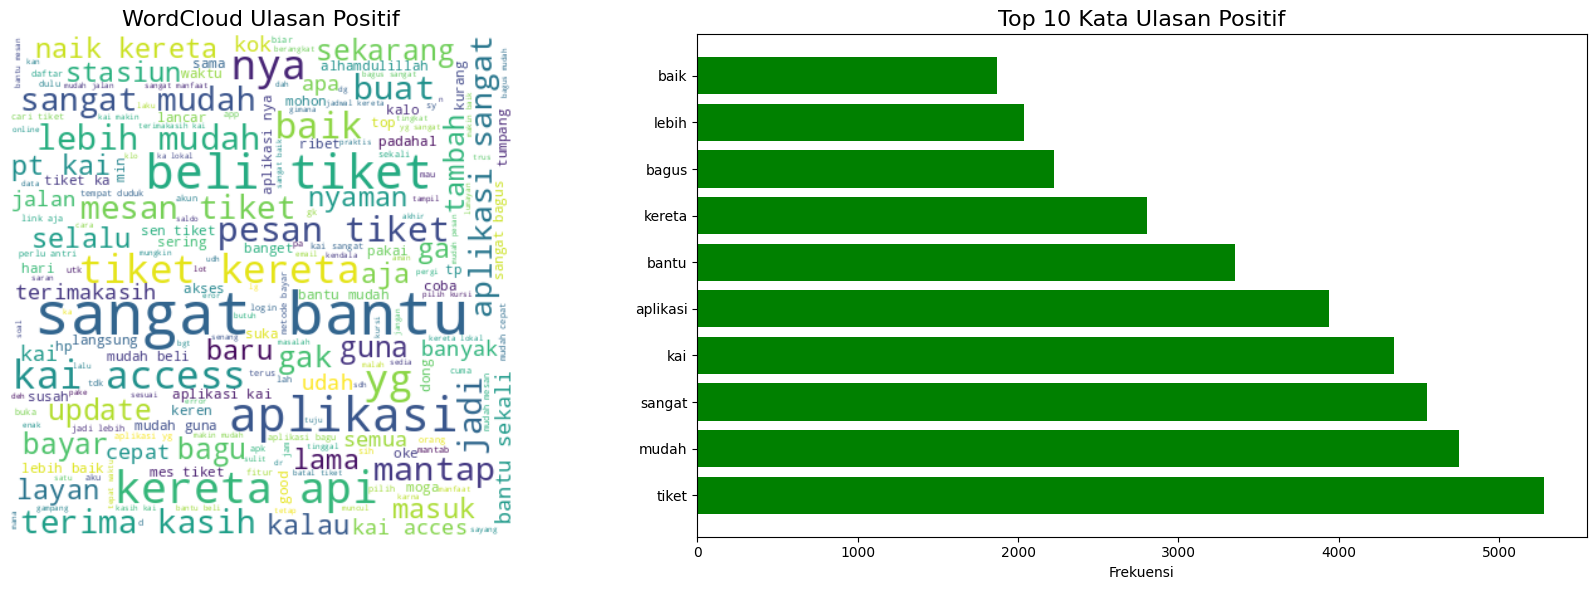

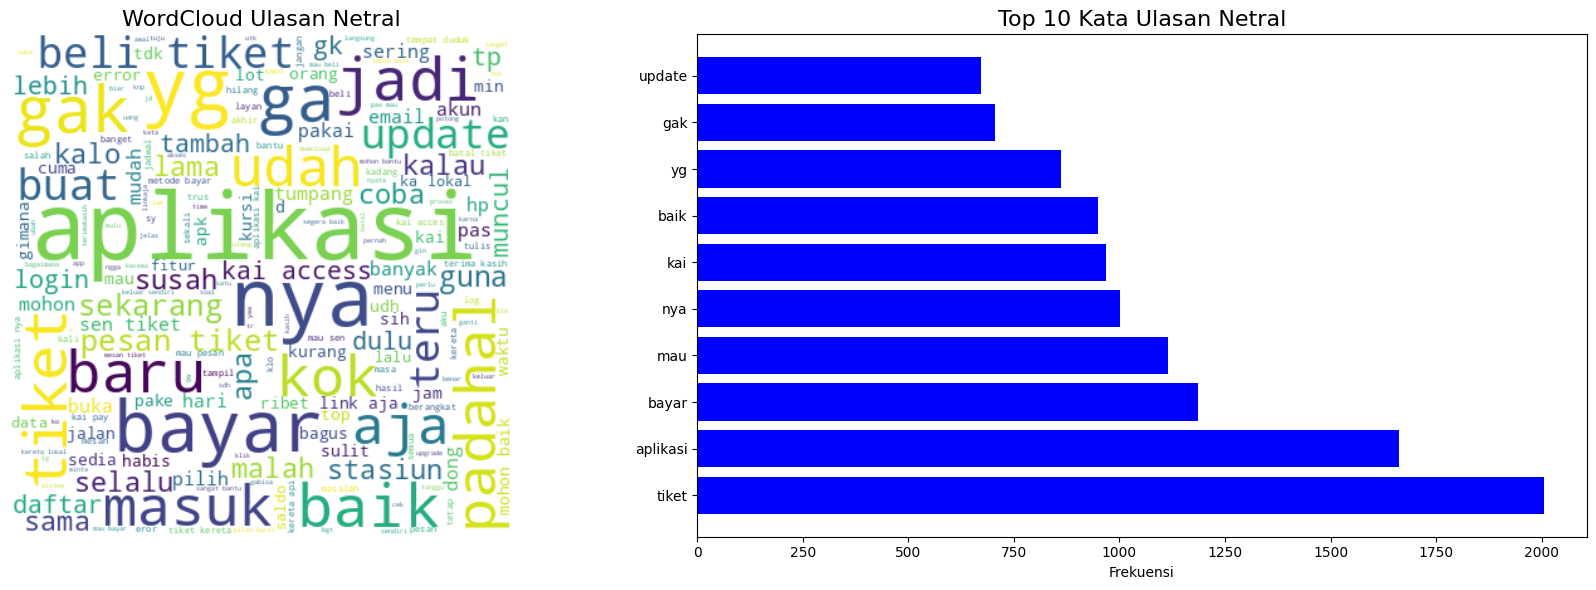

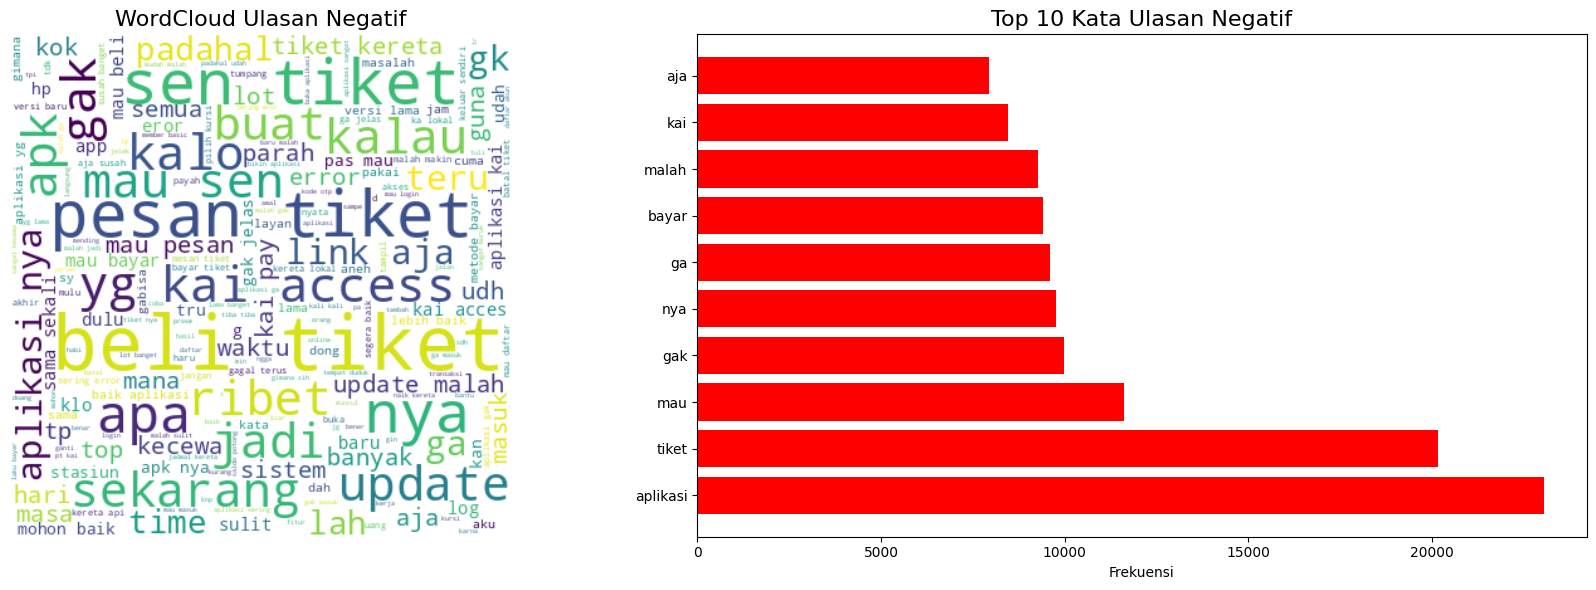

In [33]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Fungsi WordCloud
def generate_wordcloud(text):
    return WordCloud(
        width=400,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate(text)

# Fungsi Top N kata
def top_n_words(text_series, n=10):
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Persiapkan data per sentimen
sentiments = ['positif', 'netral', 'negatif']
colors = {'positif':'green', 'netral':'blue', 'negatif':'red'}

for sentiment in sentiments:
    # Gabungkan teks
    text = ' '.join(df_prep[df_prep['sentiment']==sentiment]['review_txt_stemmed'].tolist())
    top_words = top_n_words(df_prep[df_prep['sentiment']==sentiment]['review_txt_stemmed'], 10)

    # Buat figure dengan 2 subplot
    fig, axes = plt.subplots(1, 2, figsize=(18,6))

    # WordCloud
    wc = generate_wordcloud(text)
    axes[0].imshow(wc, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title(f'WordCloud Ulasan {sentiment.capitalize()}', fontsize=16)

    # Bar Chart Top 10 kata
    axes[1].barh([w[0] for w in top_words][::-1], [w[1] for w in top_words][::-1], color=colors[sentiment])
    axes[1].set_xlabel('Frekuensi')
    axes[1].invert_yaxis()
    axes[1].set_title(f'Top 10 Kata Ulasan {sentiment.capitalize()}', fontsize=16)

    plt.tight_layout()
    plt.show()

# ***Kamus Kategori Keluhan***

In [43]:
kategori_keluhan = {
    'Teknis': [
        'error', 'login', 'crash', 'bug', 'update', 'loading', 'server', 'sistem'
    ],
    'Pembayaran': [
        'bayar', 'pembayaran', 'saldo', 'gagal', 'refund', 'transaksi', 'payment'
    ],
    'UX': [
        'lambat', 'lemot', 'ribet', 'susah', 'bingung', 'tampilan', 'fitur'
    ]
}

# ***Fungsi Ambil Top 20 Kata per Kategori***

In [44]:
from collections import Counter

def top_words_by_category(df, stem_col, keywords, top_n=20):
    texts = df[df['sentiment']=='negatif'][stem_col]

    tokens = []
    for t in texts:
        for word in t.split():
            if word in keywords:
                tokens.append(word)

    return Counter(tokens).most_common(top_n)

# ***Fungsi Ambil Contoh Ulasan untuk Setiap Kata***

In [45]:
def example_reviews(df, text_col, word, n=2):
    return df[
        (df['sentiment']=='negatif') &
        (df[text_col].str.contains(rf'\b{word}\b', regex=True))
    ][text_col].head(n).tolist()

# ***Membuat Tabel Keluhan (20 Kata × Contoh Ulasan)***

In [46]:
hasil_tabel = []

for kategori, keywords in kategori_keluhan.items():

    top_words = top_words_by_category(
        df_prep,
        'review_txt_stemmed',
        keywords,
        top_n=20
    )

    for kata, frek in top_words:
        contoh = example_reviews(
            df_prep,
            'review_txt_clean',  # teks manusiawi
            kata,
            n=2
        )

        hasil_tabel.append({
            'Kategori Keluhan': kategori,
            'Kata Dominan': kata,
            'Frekuensi': frek,
            'Contoh Ulasan': " | ".join(contoh)
        })

df_keluhan_20kata = pd.DataFrame(hasil_tabel)
df_keluhan_20kata

,Kategori Keluhan,Kata Dominan,Frekuensi,Contoh Ulasan
0,Teknis,update,6470,makin di update makin banyak masalah nya | maa...
1,Teknis,login,4304,login nya susah bufeting terus tolong di kontr...
2,Teknis,error,2991,lola error | pasti selalu menjelang mudik error
3,Teknis,sistem,1740,menggunakan aplikasi bukan ny mempermudah untu...
4,Teknis,bug,1210,mohon perbaikanya ini aplikasi nge bug pas vis...
5,Teknis,loading,1205,war tiket lebaran standby dari jam pas masuk b...
6,Teknis,server,1087,kalau buat aplikasi yang bener dong sewa serve...
7,Teknis,crash,132,selalu crash | apk sering crash
8,Pembayaran,bayar,9406,aneh udah bayar refund tapi pas di refund ga |...
9,Pembayaran,saldo,3308,sudah beli tiket karena emang aplikasi nya gk ...


# ***Keluhan Teknis***

In [47]:
data_teknis = []

top_teknis = top_words_by_category(
    df_prep,
    'review_txt_stemmed',
    kategori_keluhan['Teknis'],
    top_n=20
)

for kata, frek in top_teknis:
    contoh = example_reviews(df_prep, 'review_txt_clean', kata, n=2)
    data_teknis.append({
        'Kata Dominan': kata,
        'Frekuensi': frek,
        'Contoh Ulasan': " | ".join(contoh)
    })

df_keluhan_teknis = pd.DataFrame(data_teknis)
df_keluhan_teknis

,Kata Dominan,Frekuensi,Contoh Ulasan
0,update,6470,makin di update makin banyak masalah nya | maa...
1,login,4304,login nya susah bufeting terus tolong di kontr...
2,error,2991,lola error | pasti selalu menjelang mudik error
3,sistem,1740,menggunakan aplikasi bukan ny mempermudah untu...
4,bug,1210,mohon perbaikanya ini aplikasi nge bug pas vis...
5,loading,1205,war tiket lebaran standby dari jam pas masuk b...
6,server,1087,kalau buat aplikasi yang bener dong sewa serve...
7,crash,132,selalu crash | apk sering crash


# ***Keluhan Pembayaran***

In [48]:
data_pembayaran = []

top_pembayaran = top_words_by_category(
    df_prep,
    'review_txt_stemmed',
    kategori_keluhan['Pembayaran'],
    top_n=20
)

for kata, frek in top_pembayaran:
    contoh = example_reviews(df_prep, 'review_txt_clean', kata, n=2)
    data_pembayaran.append({
        'Kata Dominan': kata,
        'Frekuensi': frek,
        'Contoh Ulasan': " | ".join(contoh)
    })

df_keluhan_pembayaran = pd.DataFrame(data_pembayaran)
df_keluhan_pembayaran

,Kata Dominan,Frekuensi,Contoh Ulasan
0,bayar,9406,aneh udah bayar refund tapi pas di refund ga |...
1,saldo,3308,sudah beli tiket karena emang aplikasi nya gk ...
2,gagal,2525,gagal terus napa nih mau pesen juga di persuli...
3,transaksi,856,sudah beli tiket karena emang aplikasi nya gk ...
4,refund,623,mau refund aja di persulit chet ngga di bales ...
5,payment,263,layanan cs gk bisa berpungsi dengan semestinya...


# ***Keluhan UX***

In [49]:
data_ux = []

top_ux = top_words_by_category(
    df_prep,
    'review_txt_stemmed',
    kategori_keluhan['UX'],
    top_n=20
)

for kata, frek in top_ux:
    contoh = example_reviews(df_prep, 'review_txt_clean', kata, n=2)
    data_ux.append({
        'Kata Dominan': kata,
        'Frekuensi': frek,
        'Contoh Ulasan': " | ".join(contoh)
    })

df_keluhan_ux = pd.DataFrame(data_ux)
df_keluhan_ux

,Kata Dominan,Frekuensi,Contoh Ulasan
0,susah,5656,kenapa susah pesen tiket buat lebaran ya padah...
1,ribet,2998,guidence untuk top upnya ribet kalimatnya aneh...
2,fitur,793,sudah lama pakai aplikasi ini tp kecewa fitur ...
3,lambat,568,tolong di optimalkan lagi terutama jadwal kere...
4,bingung,480,saya lebih suka yang lama lebih mudah di paham...


# ***Tabel Perbandingan***

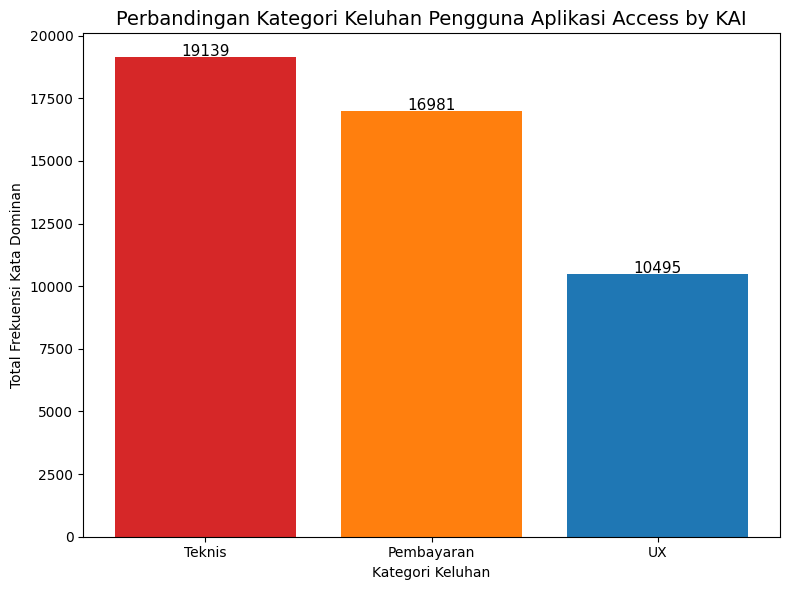

In [ ]:
import matplotlib.pyplot as plt

# Data ringkasan (sudah dibuat sebelumnya)
kategori = summary_keluhan['Kategori Keluhan']
frekuensi = summary_keluhan['Total Frekuensi']

# Warna berbeda untuk tiap kategori
colors = ['#d62728', '#ff7f0e', '#1f77b4']  # merah, oranye, biru

plt.figure(figsize=(8,6))
bars = plt.bar(kategori, frekuensi, color=colors)

plt.title('Perbandingan Kategori Keluhan Pengguna Aplikasi Access by KAI', fontsize=14)
plt.xlabel('Kategori Keluhan')
plt.ylabel('Total Frekuensi Kata Dominan')

# Tampilkan nilai di atas batang
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f'{height}',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

# ***Sentimen Positif***

In [63]:
from collections import Counter

# Ambil seluruh teks sentimen positif
positive_text = df_prep[df_prep['sentiment'] == 'positif']['review_txt_stemmed']

# Gabungkan semua kata
all_words_pos = ' '.join(positive_text).split()

# Hitung frekuensi kata
top_20_words_pos = Counter(all_words_pos).most_common(20)

# Buat DataFrame
df_top20_pos = pd.DataFrame(top_20_words_pos, columns=['Kata', 'Frekuensi'])

df_top20_pos

,Kata,Frekuensi
0,tiket,5280
1,mudah,4747
2,sangat,4551
3,kai,4346
4,aplikasi,3940
5,bantu,3352
6,kereta,2803
7,bagus,2226
8,lebih,2040
9,baik,1869


# ***Ambil Contoh Ulasan untuk Setiap Kata***

In [64]:
# Fungsi mengambil contoh ulasan untuk suatu kata
def contoh_ulasan(kata, df, n=3):
    contoh = df[
        (df['sentiment'] == 'positif') &
        (df['review_txt_stemmed'].str.contains(rf'\b{kata}\b', regex=True))
    ]['review_txt_clean'].head(n).tolist()

    return contoh

# Tambahkan kolom contoh ulasan
df_top20_pos['Contoh_Ulasan'] = df_top20_pos['Kata'].apply(
    lambda x: contoh_ulasan(x, df_prep, n=3)
)

df_top20_pos

,Kata,Frekuensi,Contoh_Ulasan
0,tiket,5280,[sebenarnya aplikasi ini memudahkan tp knp beb...
1,mudah,4747,[sebenarnya aplikasi ini memudahkan tp knp beb...
2,sangat,4551,"[sangat keren, sangat baik dan membantu, sanga..."
3,kai,4346,[sebenarnya aplikasi ini memudahkan tp knp beb...
4,aplikasi,3940,[sebenarnya aplikasi ini memudahkan tp knp beb...
5,bantu,3352,"[sangat baik dan membantu, sangat membantu sek..."
6,kereta,2803,[bagus banget jadi gk ngantri di loket semoga ...
7,bagus,2226,"[bagus banget, bagus dan bersih, bagus]"
8,lebih,2040,"[top lebih mudah, kalo bisa potongannya lebih ..."
9,baik,1869,"[sangat baik dan membantu, bagus baik, sangat ..."


### ***Tabel Akhir***

In [65]:
# Expand contoh ulasan ke baris terpisah
df_pos_expanded = df_top20_pos.explode('Contoh_Ulasan')

df_pos_expanded.rename(columns={
    'Contoh_Ulasan': 'Contoh Ulasan Pengguna'
}, inplace=True)

df_pos_expanded

,Kata,Frekuensi,Contoh Ulasan Pengguna
0,tiket,5280,sebenarnya aplikasi ini memudahkan tp knp bebe...
0,tiket,5280,kenapa war tiket lebaran tahun ini susah bange...
0,tiket,5280,untuk pemesanan tiket pergi pulang tolong dita...
1,mudah,4747,sebenarnya aplikasi ini memudahkan tp knp bebe...
1,mudah,4747,untuk pemesanan tiket pergi pulang tolong dita...
1,mudah,4747,top lebih mudah
2,sangat,4551,sangat keren
2,sangat,4551,sangat baik dan membantu
2,sangat,4551,sangat membantu sekali pokoknya mantaf pokokny...
3,kai,4346,sebenarnya aplikasi ini memudahkan tp knp bebe...


In [70]:
# Kamus kategori kata positif
kategori_kata = {
    'UX': [
        'tampilan', 'desain', 'fitur', 'aplikasi', 'menu', 'update', 'ringan'
    ],
    'Kemudahan': [
        'mudah', 'cepat', 'praktis', 'simple', 'langsung', 'bantu'
    ],
    'Layanan': [
        'tiket', 'kereta', 'kai', 'layanan', 'beli', 'pesan', 'bayar', 'akses'
    ]
}

In [71]:
def tentukan_kategori(kata):
    for kategori, daftar_kata in kategori_kata.items():
        if kata in daftar_kata:
            return kategori
    return 'Lainnya'

In [72]:
df_top20_pos['Kategori'] = df_top20_pos['Kata'].apply(tentukan_kategori)

df_top20_pos

,Kata,Frekuensi,Contoh_Ulasan,Kategori
0,tiket,5280,[sebenarnya aplikasi ini memudahkan tp knp beb...,Layanan
1,mudah,4747,[sebenarnya aplikasi ini memudahkan tp knp beb...,Kemudahan
2,sangat,4551,"[sangat keren, sangat baik dan membantu, sanga...",Lainnya
3,kai,4346,[sebenarnya aplikasi ini memudahkan tp knp beb...,Layanan
4,aplikasi,3940,[sebenarnya aplikasi ini memudahkan tp knp beb...,UX
5,bantu,3352,"[sangat baik dan membantu, sangat membantu sek...",Kemudahan
6,kereta,2803,[bagus banget jadi gk ngantri di loket semoga ...,Layanan
7,bagus,2226,"[bagus banget, bagus dan bersih, bagus]",Lainnya
8,lebih,2040,"[top lebih mudah, kalo bisa potongannya lebih ...",Lainnya
9,baik,1869,"[sangat baik dan membantu, bagus baik, sangat ...",Lainnya


In [73]:
rekap_kategori = (
    df_top20_pos
    .groupby('Kategori')['Frekuensi']
    .sum()
    .reset_index()
    .sort_values(by='Frekuensi', ascending=False)
)

rekap_kategori

,Kategori,Frekuensi
1,Lainnya,19982
2,Layanan,16614
0,Kemudahan,8099
3,UX,3940


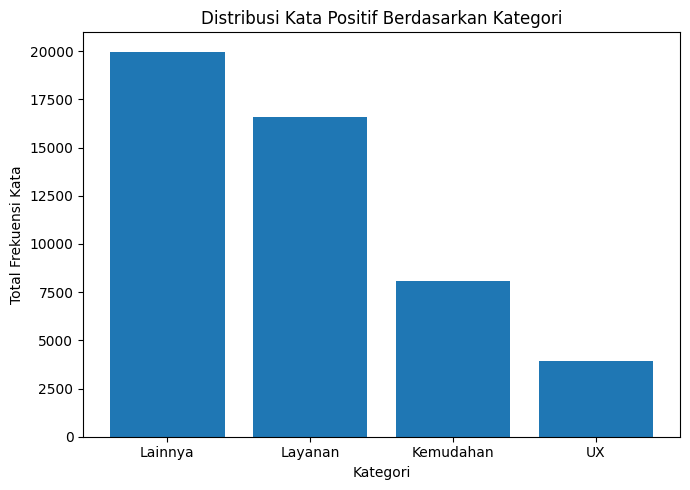

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(
    rekap_kategori['Kategori'],
    rekap_kategori['Frekuensi']
)

plt.title('Distribusi Kata Positif Berdasarkan Kategori')
plt.xlabel('Kategori')
plt.ylabel('Total Frekuensi Kata')
plt.tight_layout()
plt.show()

In [55]:
# Hitung total frekuensi per kategori
summary_keluhan = pd.DataFrame({
    'Kategori Keluhan': ['Teknis', 'Pembayaran', 'UX'],
    'Total Frekuensi': [
        df_keluhan_teknis['Frekuensi'].sum(),
        df_keluhan_pembayaran['Frekuensi'].sum(),
        df_keluhan_ux['Frekuensi'].sum()
    ]
})

summary_keluhan

,Kategori Keluhan,Total Frekuensi
0,Teknis,19139
1,Pembayaran,16981
2,UX,10495


In [66]:
# Kamus kategori kata positif
kategori_kata = {
    'UX': [
        'tampilan', 'desain', 'fitur', 'aplikasi', 'menu', 'update', 'ringan'
    ],
    'Kemudahan': [
        'mudah', 'cepat', 'praktis', 'simple', 'langsung', 'bantu'
    ],
    'Layanan': [
        'tiket', 'kereta', 'kai', 'layanan', 'beli', 'pesan', 'bayar', 'akses'
    ]
}

In [67]:
def tentukan_kategori(kata):
    for kategori, daftar_kata in kategori_kata.items():
        if kata in daftar_kata:
            return kategori
    return 'Lainnya'

In [68]:
df_top20_pos['Kategori'] = df_top20_pos['Kata'].apply(tentukan_kategori)

df_top20_pos

,Kata,Frekuensi,Contoh_Ulasan,Kategori
0,tiket,5280,[sebenarnya aplikasi ini memudahkan tp knp beb...,Layanan
1,mudah,4747,[sebenarnya aplikasi ini memudahkan tp knp beb...,Kemudahan
2,sangat,4551,"[sangat keren, sangat baik dan membantu, sanga...",Lainnya
3,kai,4346,[sebenarnya aplikasi ini memudahkan tp knp beb...,Layanan
4,aplikasi,3940,[sebenarnya aplikasi ini memudahkan tp knp beb...,UX
5,bantu,3352,"[sangat baik dan membantu, sangat membantu sek...",Kemudahan
6,kereta,2803,[bagus banget jadi gk ngantri di loket semoga ...,Layanan
7,bagus,2226,"[bagus banget, bagus dan bersih, bagus]",Lainnya
8,lebih,2040,"[top lebih mudah, kalo bisa potongannya lebih ...",Lainnya
9,baik,1869,"[sangat baik dan membantu, bagus baik, sangat ...",Lainnya


# ***Tampilan Sentimen Positif tiap Kategori***

In [75]:
# Kamus kategori kata positif
kategori_kata_positif = {
    'UX': [
        'aplikasi', 'tampilan', 'fitur', 'desain', 'menu', 'update', 'ringan'
    ],
    'Kemudahan': [
        'mudah', 'cepat', 'praktis', 'bantu', 'langsung', 'simple'
    ],
    'Layanan': [
        'tiket', 'kereta', 'kai', 'beli', 'pesan', 'akses', 'layanan'
    ]
}

In [76]:
def tentukan_kategori_positif(kata):
    for kategori, daftar in kategori_kata_positif.items():
        if kata in daftar:
            return kategori
    return None

In [77]:
from collections import Counter
import pandas as pd

positive_text = df_prep[df_prep['sentiment'] == 'positif']['review_txt_stemmed']
all_words = ' '.join(positive_text).split()

top20_pos = Counter(all_words).most_common(20)

df_top20_pos = pd.DataFrame(top20_pos, columns=['Kata', 'Frekuensi'])
df_top20_pos['Kategori'] = df_top20_pos['Kata'].apply(tentukan_kategori_positif)

# Ambil hanya yang masuk 3 kategori
df_top20_pos = df_top20_pos.dropna()

df_top20_pos

,Kata,Frekuensi,Kategori
0,tiket,5280,Layanan
1,mudah,4747,Kemudahan
3,kai,4346,Layanan
4,aplikasi,3940,UX
5,bantu,3352,Kemudahan
6,kereta,2803,Layanan
12,beli,1645,Layanan
18,pesan,1154,Layanan


In [78]:
def ambil_contoh_ulasan(kata, df, n=2):
    contoh = df[
        (df['sentiment'] == 'positif') &
        (df['review_txt_stemmed'].str.contains(rf'\b{kata}\b', regex=True))
    ]['review_txt_clean'].head(n).tolist()
    return contoh

In [79]:
hasil_kategori = []

for _, row in df_top20_pos.iterrows():
    contoh_ulasan = ambil_contoh_ulasan(row['Kata'], df_prep, n=2)
    for ulasan in contoh_ulasan:
        hasil_kategori.append({
            'Kategori': row['Kategori'],
            'Kata Dominan': row['Kata'],
            'Frekuensi': row['Frekuensi'],
            'Contoh Ulasan Positif': ulasan
        })

df_kategori_positif = pd.DataFrame(hasil_kategori)

df_kategori_positif

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Positif
0,Layanan,tiket,5280,sebenarnya aplikasi ini memudahkan tp knp bebe...
1,Layanan,tiket,5280,kenapa war tiket lebaran tahun ini susah bange...
2,Kemudahan,mudah,4747,sebenarnya aplikasi ini memudahkan tp knp bebe...
3,Kemudahan,mudah,4747,untuk pemesanan tiket pergi pulang tolong dita...
4,Layanan,kai,4346,sebenarnya aplikasi ini memudahkan tp knp bebe...
5,Layanan,kai,4346,kepada yth bapak ibu yang berwenang di pt kai ...
6,UX,aplikasi,3940,sebenarnya aplikasi ini memudahkan tp knp bebe...
7,UX,aplikasi,3940,transportasi darat paling nyaman aplikasi bgus...
8,Kemudahan,bantu,3352,sangat baik dan membantu
9,Kemudahan,bantu,3352,sangat membantu sekali pokoknya mantaf pokokny...


# ***Kemudahan***

In [81]:
df_kemudahan = df_kategori_positif[df_kategori_positif['Kategori'] == 'Kemudahan'].head(5)
df_kemudahan

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Positif
2,Kemudahan,mudah,4747,sebenarnya aplikasi ini memudahkan tp knp bebe...
3,Kemudahan,mudah,4747,untuk pemesanan tiket pergi pulang tolong dita...
8,Kemudahan,bantu,3352,sangat baik dan membantu
9,Kemudahan,bantu,3352,sangat membantu sekali pokoknya mantaf pokokny...


# ***UX***

In [80]:
df_ux = df_kategori_positif[df_kategori_positif['Kategori'] == 'UX'].head(5)
df_ux

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Positif
6,UX,aplikasi,3940,sebenarnya aplikasi ini memudahkan tp knp bebe...
7,UX,aplikasi,3940,transportasi darat paling nyaman aplikasi bgus...


# ***Layanan***

In [82]:
df_layanan = df_kategori_positif[df_kategori_positif['Kategori'] == 'Layanan'].head(5)
df_layanan

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Positif
0,Layanan,tiket,5280,sebenarnya aplikasi ini memudahkan tp knp bebe...
1,Layanan,tiket,5280,kenapa war tiket lebaran tahun ini susah bange...
4,Layanan,kai,4346,sebenarnya aplikasi ini memudahkan tp knp bebe...
5,Layanan,kai,4346,kepada yth bapak ibu yang berwenang di pt kai ...
10,Layanan,kereta,2803,bagus banget jadi gk ngantri di loket semoga s...


# ***Sentimen Netral***

In [83]:
# Kamus kategori kata netral
kategori_kata_netral = {
    'UX': [
        'aplikasi', 'tampilan', 'fitur', 'menu', 'update', 'versi'
    ],
    'Kemudahan': [
        'mudah', 'cepat', 'praktis', 'bantu', 'langsung'
    ],
    'Layanan': [
        'tiket', 'kereta', 'kai', 'beli', 'pesan', 'bayar', 'akses'
    ]
}

# ***Fungsi Menentukan Kategori Kata Netral***

In [84]:
def tentukan_kategori_netral(kata):
    for kategori, daftar in kategori_kata_netral.items():
        if kata in daftar:
            return kategori
    return None

# ***Ambil 20 Kata Teratas – Sentimen Netral***

In [85]:
from collections import Counter
import pandas as pd

# Ambil teks sentimen netral
netral_text = df_prep[df_prep['sentiment'] == 'netral']['review_txt_stemmed']

# Gabungkan dan hitung frekuensi
all_words_netral = ' '.join(netral_text).split()
top20_netral = Counter(all_words_netral).most_common(20)

df_top20_netral = pd.DataFrame(top20_netral, columns=['Kata', 'Frekuensi'])

# Tentukan kategori
df_top20_netral['Kategori'] = df_top20_netral['Kata'].apply(tentukan_kategori_netral)

# Ambil hanya yang masuk kategori
df_top20_netral = df_top20_netral.dropna()

df_top20_netral

,Kata,Frekuensi,Kategori
0,tiket,2006,Layanan
1,aplikasi,1661,UX
2,bayar,1186,Layanan
5,kai,968,Layanan
9,update,673,UX
13,kereta,595,Layanan
18,beli,538,Layanan


# ***Fungsi Ambil Contoh Ulasan Netral***

In [86]:
def ambil_contoh_ulasan_netral(kata, df, n=2):
    contoh = df[
        (df['sentiment'] == 'netral') &
        (df['review_txt_stemmed'].str.contains(rf'\b{kata}\b', regex=True))
    ]['review_txt_clean'].head(n).tolist()
    return contoh

# ***Bangun Tabel Akhir – Netral + Contoh Ulasan***

In [87]:
hasil_kategori_netral = []

for _, row in df_top20_netral.iterrows():
    contoh_ulasan = ambil_contoh_ulasan_netral(row['Kata'], df_prep, n=2)
    for ulasan in contoh_ulasan:
        hasil_kategori_netral.append({
            'Kategori': row['Kategori'],
            'Kata Dominan': row['Kata'],
            'Frekuensi': row['Frekuensi'],
            'Contoh Ulasan Netral': ulasan
        })

df_kategori_netral = pd.DataFrame(hasil_kategori_netral)

df_kategori_netral

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Netral
0,Layanan,tiket,2006,secara aplikasi sudah bagus min yang mau saya ...
1,Layanan,tiket,2006,curang mau pesen tiket kereta tanggal maret di...
2,UX,aplikasi,1661,parah parah parahhhhhh aplikasi trouble gatau ...
3,UX,aplikasi,1661,secara aplikasi sudah bagus min yang mau saya ...
4,Layanan,bayar,1186,metode pembayaran lewat shopeepay gak bisa err...
5,Layanan,bayar,1186,baru update per pengalaman pesen terbaru pasca...
6,Layanan,kai,968,aplikasi kai access ada gangguan kah mau updat...
7,Layanan,kai,968,setelah melakukan perbaikan sekarang railfood ...
8,UX,update,673,update aplikasi mulu
9,UX,update,673,semenjak update aplikasi ini kenapa saya tidak...


# ***Pisahkan Menjadi 3 Tabel Netral (Minimal 5 Baris)***

# ***UX Netral***

In [88]:
df_netral_ux = df_kategori_netral[df_kategori_netral['Kategori'] == 'UX'].head(5)
df_netral_ux

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Netral
2,UX,aplikasi,1661,parah parah parahhhhhh aplikasi trouble gatau ...
3,UX,aplikasi,1661,secara aplikasi sudah bagus min yang mau saya ...
8,UX,update,673,update aplikasi mulu
9,UX,update,673,semenjak update aplikasi ini kenapa saya tidak...


# ***Layanan (Netral)***

In [90]:
df_netral_layanan = df_kategori_netral[df_kategori_netral['Kategori'] == 'Layanan'].head(5)
df_netral_layanan

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Netral
0,Layanan,tiket,2006,secara aplikasi sudah bagus min yang mau saya ...
1,Layanan,tiket,2006,curang mau pesen tiket kereta tanggal maret di...
4,Layanan,bayar,1186,metode pembayaran lewat shopeepay gak bisa err...
5,Layanan,bayar,1186,baru update per pengalaman pesen terbaru pasca...
6,Layanan,kai,968,aplikasi kai access ada gangguan kah mau updat...


# ***Kemudahan (Netral)***

In [89]:
df_netral_kemudahan = df_kategori_netral[df_kategori_netral['Kategori'] == 'Kemudahan'].head(5)
df_netral_kemudahan

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Netral


# ***ANALISIS SENTIMEN NEGATIF***

# ***Kamus Kategori Kata – Sentimen Negatif***

In [92]:
# Kamus kategori kata negatif
kategori_kata_negatif = {
    'UX': [
        'aplikasi', 'error', 'lemot', 'hang', 'crash', 'update', 'buka'
    ],
    'Kemudahan': [
        'susah', 'ribet', 'lama', 'sulit', 'bingung', 'gagal'
    ],
    'Layanan': [
        'tiket', 'bayar', 'pesan', 'refund', 'kai', 'transaksi', 'saldo'
    ]
}

# ***Fungsi Menentukan Kategori Kata Negatif***

In [93]:
def tentukan_kategori_negatif(kata):
    for kategori, daftar in kategori_kata_negatif.items():
        if kata in daftar:
            return kategori
    return None

# ***Ambil 20 Kata Teratas – Sentimen Negatif***

In [94]:
from collections import Counter
import pandas as pd

# Ambil teks sentimen negatif
negatif_text = df_prep[df_prep['sentiment'] == 'negatif']['review_txt_stemmed']

# Gabungkan dan hitung frekuensi
all_words_negatif = ' '.join(negatif_text).split()
top20_negatif = Counter(all_words_negatif).most_common(20)

df_top20_negatif = pd.DataFrame(top20_negatif, columns=['Kata', 'Frekuensi'])

# Tentukan kategori
df_top20_negatif['Kategori'] = df_top20_negatif['Kata'].apply(tentukan_kategori_negatif)

# Ambil hanya kata yang masuk kategori
df_top20_negatif = df_top20_negatif.dropna()

df_top20_negatif

,Kata,Frekuensi,Kategori
0,aplikasi,23052,UX
1,tiket,20166,Layanan
6,bayar,9406,Layanan
8,kai,8454,Layanan
13,update,6470,UX
17,susah,5656,Kemudahan
18,lama,5577,Kemudahan


# ***Fungsi Ambil Contoh Ulasan Negatif***

In [96]:
def ambil_contoh_ulasan_negatif(kata, df, n=2):
    contoh = df[
        (df['sentiment'] == 'negatif') &
        (df['review_txt_stemmed'].str.contains(rf'\b{kata}\b', regex=True))
    ]['review_txt_clean'].head(n).tolist()
    return contoh

# ***Bangun Tabel Akhir – Negatif + Contoh Ulasan***

In [97]:
hasil_kategori_negatif = []

for _, row in df_top20_negatif.iterrows():
    contoh_ulasan = ambil_contoh_ulasan_negatif(row['Kata'], df_prep, n=2)
    for ulasan in contoh_ulasan:
        hasil_kategori_negatif.append({
            'Kategori': row['Kategori'],
            'Kata Dominan': row['Kata'],
            'Frekuensi': row['Frekuensi'],
            'Contoh Ulasan Negatif': ulasan
        })

df_kategori_negatif = pd.DataFrame(hasil_kategori_negatif)

df_kategori_negatif

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Negatif
0,UX,aplikasi,23052,sudah lama pakai aplikasi ini tp kecewa fitur ...
1,UX,aplikasi,23052,aplikasi sampah tiap tahun begini terus bukan ...
2,Layanan,tiket,20166,payah nge war tiket mudik tiap tahun seperti h...
3,Layanan,tiket,20166,malam berturut turut cari tiket lebaran pas ja...
4,Layanan,bayar,9406,aplikasi sampah tiap tahun begini terus bukan ...
5,Layanan,bayar,9406,layanan cs gk bisa berpungsi dengan semestinya...
6,Layanan,kai,8454,sudah lama pakai aplikasi ini tp kecewa fitur ...
7,Layanan,kai,8454,menggunakan aplikasi bukan ny mempermudah untu...
8,UX,update,6470,makin di update makin banyak masalah nya
9,UX,update,6470,maaf padahal saya sudah menunggu jam malam aga...


# ***Pisahkan Menjadi 3 Tabel Negatif (Minimal 5 Baris)***

# ***UX Negatif***

In [98]:
df_negatif_ux = df_kategori_negatif[df_kategori_negatif['Kategori'] == 'UX'].head(5)
df_negatif_ux

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Negatif
0,UX,aplikasi,23052,sudah lama pakai aplikasi ini tp kecewa fitur ...
1,UX,aplikasi,23052,aplikasi sampah tiap tahun begini terus bukan ...
8,UX,update,6470,makin di update makin banyak masalah nya
9,UX,update,6470,maaf padahal saya sudah menunggu jam malam aga...


# ***Kemudahan (Negatif)***

In [99]:
df_negatif_kemudahan = df_kategori_negatif[df_kategori_negatif['Kategori'] == 'Kemudahan'].head(5)
df_negatif_kemudahan

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Negatif
10,Kemudahan,susah,5656,kenapa susah pesen tiket buat lebaran ya padah...
11,Kemudahan,susah,5656,semakin hari semakin susah buat pesan tiket li...
12,Kemudahan,lama,5577,sudah lama pakai aplikasi ini tp kecewa fitur ...
13,Kemudahan,lama,5577,udeh hari war tiket selalu on time jam kreta m...


# ***Layanan (Negatif)***

In [100]:
df_negatif_layanan = df_kategori_negatif[df_kategori_negatif['Kategori'] == 'Layanan'].head(5)
df_negatif_layanan

,Kategori,Kata Dominan,Frekuensi,Contoh Ulasan Negatif
2,Layanan,tiket,20166,payah nge war tiket mudik tiap tahun seperti h...
3,Layanan,tiket,20166,malam berturut turut cari tiket lebaran pas ja...
4,Layanan,bayar,9406,aplikasi sampah tiap tahun begini terus bukan ...
5,Layanan,bayar,9406,layanan cs gk bisa berpungsi dengan semestinya...
6,Layanan,kai,8454,sudah lama pakai aplikasi ini tp kecewa fitur ...


# ***Grafik perbandingan POSITIF vs NETRAL vs NEGATIF per kategori***

In [101]:
import pandas as pd

# Rekap jumlah kemunculan per kategori
rekap_pos = df_kategori_positif.groupby('Kategori').size().reset_index(name='Positif')
rekap_net = df_kategori_netral.groupby('Kategori').size().reset_index(name='Netral')
rekap_neg = df_kategori_negatif.groupby('Kategori').size().reset_index(name='Negatif')

# Gabungkan semua
df_rekap = rekap_pos.merge(rekap_net, on='Kategori', how='outer') \
                    .merge(rekap_neg, on='Kategori', how='outer') \
                    .fillna(0)

df_rekap

,Kategori,Positif,Netral,Negatif
0,Kemudahan,4,0.0,4
1,Layanan,10,10.0,6
2,UX,2,4.0,4


# ***Grafik Perbandingan Hasil***

# ***Rekap Data Terbaru per Kategori & Sentimen***

In [102]:
import pandas as pd

# Rekap jumlah data per kategori dan sentimen
rekap_pos = df_kategori_positif.groupby('Kategori').size().reset_index(name='Positif')
rekap_net = df_kategori_netral.groupby('Kategori').size().reset_index(name='Netral')
rekap_neg = df_kategori_negatif.groupby('Kategori').size().reset_index(name='Negatif')

# Gabungkan semua rekap
df_rekap = (
    rekap_pos
    .merge(rekap_net, on='Kategori', how='outer')
    .merge(rekap_neg, on='Kategori', how='outer')
    .fillna(0)
)

df_rekap

,Kategori,Positif,Netral,Negatif
0,Kemudahan,4,0.0,4
1,Layanan,10,10.0,6
2,UX,2,4.0,4


# ***Grafik Batang Perbandingan (Versi Final)***

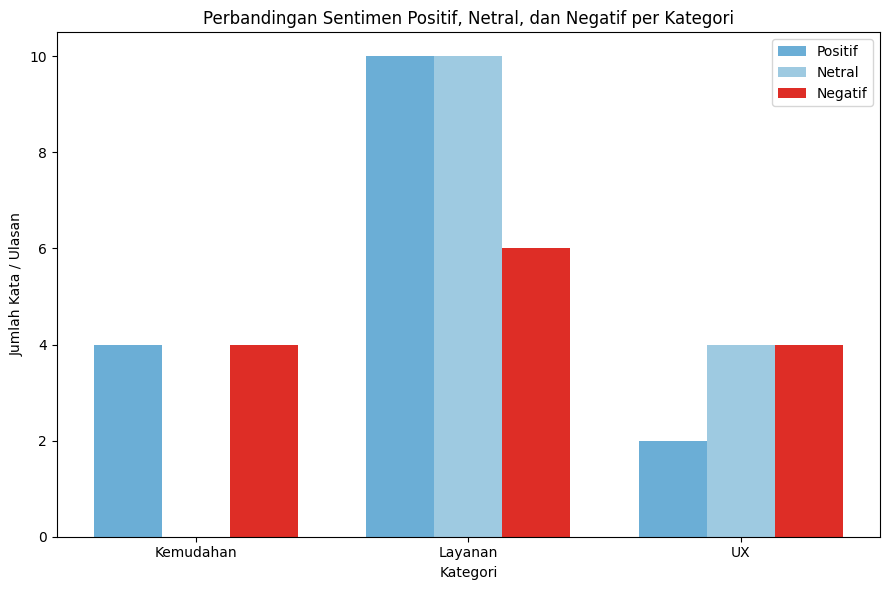

In [103]:
import matplotlib.pyplot as plt
import numpy as np

kategori = df_rekap['Kategori']
positif = df_rekap['Positif']
netral = df_rekap['Netral']
negatif = df_rekap['Negatif']

x = np.arange(len(kategori))
width = 0.25

plt.figure(figsize=(9,6))

plt.bar(x - width, positif, width, label='Positif', color='#6BAED6')   # biru muda
plt.bar(x, netral, width, label='Netral', color='#9ECAE1')            # biru pucat
plt.bar(x + width, negatif, width, label='Negatif', color='#DE2D26')  # merah lembut

plt.xticks(x, kategori)
plt.xlabel('Kategori')
plt.ylabel('Jumlah Kata / Ulasan')
plt.title('Perbandingan Sentimen Positif, Netral, dan Negatif per Kategori')
plt.legend()

plt.tight_layout()
plt.show()

# ***Simpan Grafik ke File PNG***

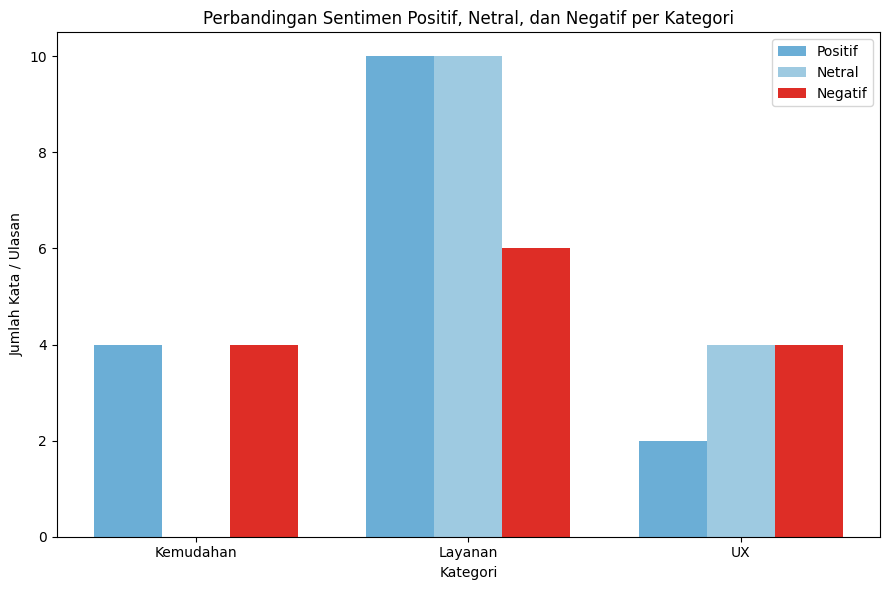

In [104]:
plt.figure(figsize=(9,6))
plt.bar(x - width, positif, width, label='Positif', color='#6BAED6')
plt.bar(x, netral, width, label='Netral', color='#9ECAE1')
plt.bar(x + width, negatif, width, label='Negatif', color='#DE2D26')

plt.xticks(x, kategori)
plt.xlabel('Kategori')
plt.ylabel('Jumlah Kata / Ulasan')
plt.title('Perbandingan Sentimen Positif, Netral, dan Negatif per Kategori')
plt.legend()
plt.tight_layout()

plt.savefig('perbandingan_sentimen_per_kategori.png', dpi=300)
plt.show()

# ***Kode Untuk Menampilkan Grafik Batang Distribusi Sentimen***

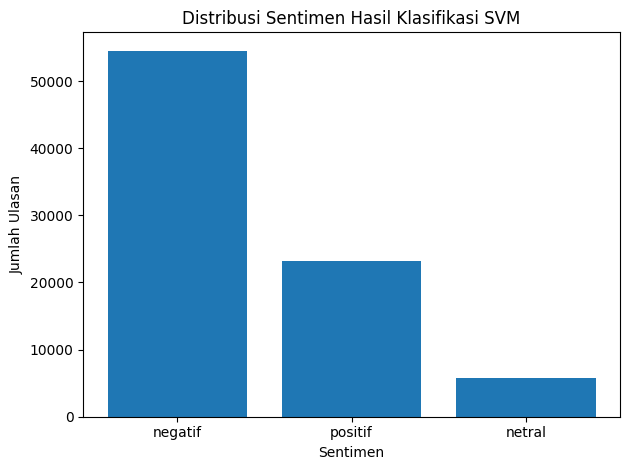

In [57]:
import matplotlib.pyplot as plt

# Hitung distribusi sentimen
sentiment_counts = df_prep['sentiment'].value_counts()

plt.figure()
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Distribusi Sentimen Hasil Klasifikasi SVM")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.tight_layout()
plt.show()

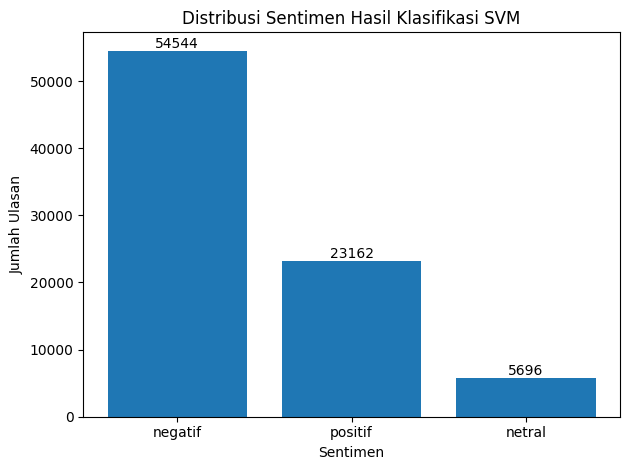

In [58]:
plt.figure()
bars = plt.bar(sentiment_counts.index, sentiment_counts.values)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             str(height), ha='center', va='bottom')

plt.title("Distribusi Sentimen Hasil Klasifikasi SVM")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.tight_layout()
plt.show()

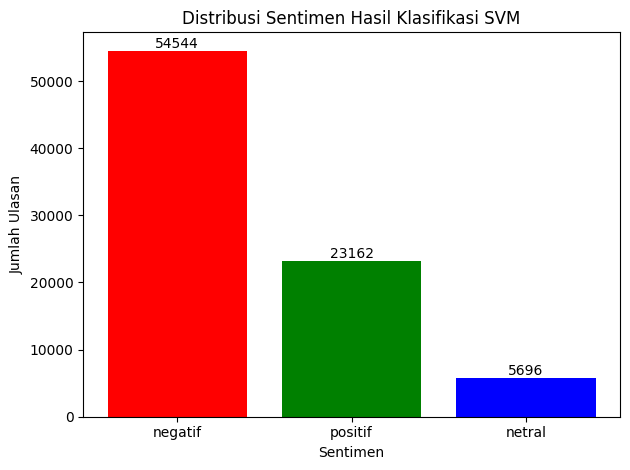

In [59]:
import matplotlib.pyplot as plt

# Hitung distribusi sentimen
sentiment_counts = df_prep['sentiment'].value_counts()

plt.figure()
bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=['red', 'green', 'blue']  # sesuaikan urutan jika perlu
)

plt.title("Distribusi Sentimen Hasil Klasifikasi SVM")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")

# Label jumlah di atas batang
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

# ***Confusion Matrix***

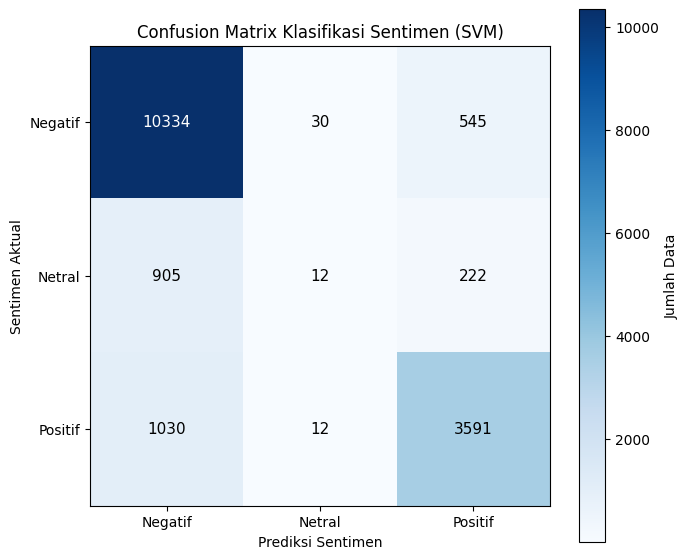

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Label sentimen
sentiment_labels = ['Negatif', 'Netral', 'Positif']

plt.figure(figsize=(7, 6))

# Gunakan colormap biru lembut
plt.imshow(cm, cmap='Blues')

plt.colorbar(label='Jumlah Data')

# Label sumbu
plt.xticks(
    ticks=np.arange(len(sentiment_labels)),
    labels=sentiment_labels
)
plt.yticks(
    ticks=np.arange(len(sentiment_labels)),
    labels=sentiment_labels
)

plt.xlabel('Prediksi Sentimen')
plt.ylabel('Sentimen Aktual')
plt.title('Confusion Matrix Klasifikasi Sentimen (SVM)')

# Tambahkan nilai di setiap sel
threshold = cm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            fontsize=11,
            color='white' if cm[i, j] > threshold else 'black'
        )

plt.tight_layout()
plt.show()

# ***Analisis Kuantitatif dari Confusion Matrix***

In [61]:
import pandas as pd

cm_df = pd.DataFrame(
    cm,
    index=[f'Aktual_{s}' for s in sentiment_labels],
    columns=[f'Prediksi_{s}' for s in sentiment_labels]
)

cm_df

,Prediksi_Negatif,Prediksi_Netral,Prediksi_Positif
Aktual_Negatif,10334,30,545
Aktual_Netral,905,12,222
Aktual_Positif,1030,12,3591
